<div style="background: linear-gradient(135deg, #4a148c 0%, #6a1b9a 50%, #7b1fa2 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 3</h1>
  <h2 style="color:#e1bee7; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">SLIM əдісі жəне Implicit Feedback</h2>
  <p style="color:#f3e5f5; font-size:1em; margin:0;">SLIM · ElasticNet · iALS · BPR · Сенімділік Матрицасы · NDCG@K · MAP@K · Precision@K</p>
</div>

## Кіріспе

Бұл зертхана екі маңызды тақырыпты жан-жақты қамтиды:

**SLIM** (Sparse Linear Models for Top-N Recommendation) — 2011 жылы ұсынылған тиімді əдіс. Item-item салмақ матрицасын ElasticNet регрессиясымен үйренеді. Negative feedback мəселесін шешпейді жəне тек positive implicit feedback-ке арналған.

**Implicit Feedback** — пайдаланушы əрекеттері: clicks, purchases, watch time, plays. Explicit рейтингтерден əлдеқайда мол, бірақ шулы жəне бiрмəнді емес — «мен мұны 5 рет ойнадым, бірақ ұнатпаймын» деп болмайды.

## Оқу Мақсаттары

- SLIM ElasticNet регрессиясы арқылы item-item W матрицасын үйрете аласыз
- alpha жəне l1_ratio гиперпараметрлерінің W сиректігіне əсерін байқайсыз
- Implicit feedback деректерін сенімділік матрицасына (Confidence) айналдыра аласыз
- iALS (implicit ALS) принципін іске асыра аласыз
- Precision@K, Recall@K, NDCG@K, MAP@K метрикаларын есептеп салыстыра аласыз
- Барлық əдістерді (CF, ALS, SLIM, iALS) бір жинақты салыстыруда бейнелей аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Кітапханалар жүктелді.")

Кітапханалар жүктелді.


## 2-бөлім: Деректерді Дайындау

In [2]:
# Implicit feedback деректері — e-commerce стилі
N_USERS = 300
N_ITEMS = 200

# Пайдаланушы-өнім əрекет матрицасы (purchases, clicks...)
# Зипф заңы бойынша: аз пайдаланушы — мол əрекет, көп пайдаланушы — аз əрекет
item_popularity = np.random.zipf(1.5, N_ITEMS).astype(float)
item_popularity = item_popularity / item_popularity.max()

implicit_raw = np.zeros((N_USERS, N_ITEMS))
for u in range(N_USERS):
    n_interactions = np.random.poisson(15)   # əр пайдаланушының əрекет саны
    probs   = item_popularity / item_popularity.sum()
    items   = np.random.choice(N_ITEMS, size=min(n_interactions, N_ITEMS),
                               replace=False, p=probs)
    counts  = np.random.randint(1, 20, len(items))
    implicit_raw[u, items] = counts

print(f"Матрица: {N_USERS}×{N_ITEMS}")
print(f"Нөлдік емес элементтер: {(implicit_raw > 0).sum()}")
print(f"Тығыздық: {(implicit_raw > 0).mean():.2%}")
print(f"Əрекет жиілігі: мин={implicit_raw[implicit_raw>0].min():.0f}, "
      f"макс={implicit_raw.max():.0f}, орт={implicit_raw[implicit_raw>0].mean():.1f}")

Матрица: 300×200
Нөлдік емес элементтер: 4475
Тығыздық: 7.46%
Əрекет жиілігі: мин=1, макс=19, орт=10.2


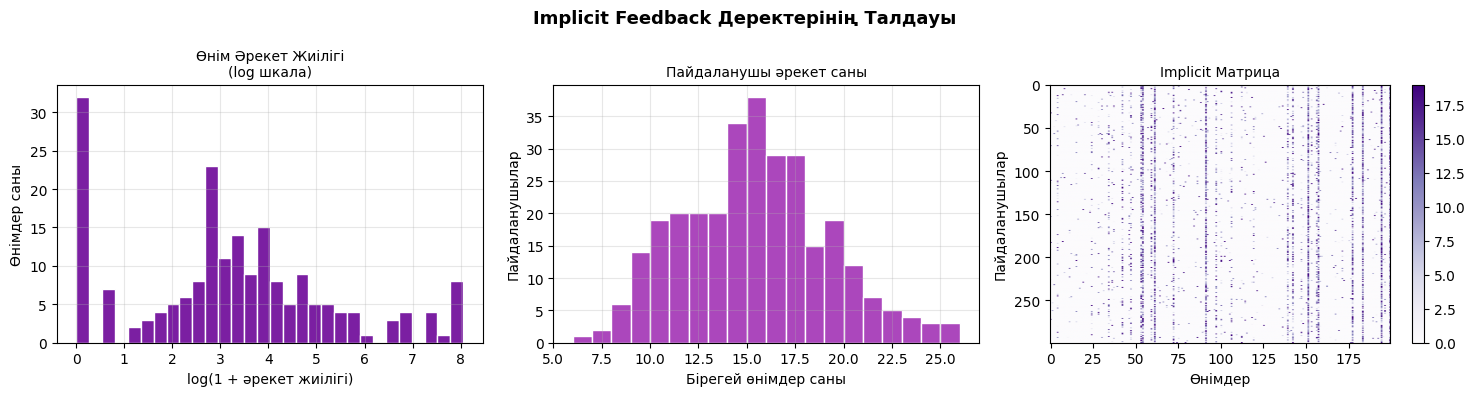

In [3]:
# ============================================================
### TODO ###
# Implicit feedback деректерін 3 графикте талдаңыз:
#   1) Өнім əрекет жиілігінің log-үлестірімі
#   2) Пайдаланушы əрекет санының үлестірімі
#   3) Implicit матрицасын imshow
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Implicit Feedback Деректерінің Талдауы', fontsize=13, fontweight='bold')

# 1) Өнім əрекет жиілігі
item_activity = implicit_raw.sum(axis=0)
axes[0].hist(np.log1p(item_activity), bins=30, color='#7b1fa2', edgecolor='white')
axes[0].set_title('Өнім Əрекет Жиілігі\n(log шкала)', fontsize=10)
axes[0].set_xlabel('log(1 + əрекет жиілігі)')
axes[0].set_ylabel('Өнімдер саны')
axes[0].grid(True, alpha=0.3)

# 2) Пайдаланушы əрекет саны
user_activity = ( implicit_raw > 0).sum(axis=1)   # implicit_raw
axes[1].hist(user_activity, bins=20, color='#ab47bc', edgecolor='white')   # user_activity
axes[1].set_title('Пайдаланушы əрекет саны', fontsize=10)
axes[1].set_xlabel('Бірегей өнімдер саны')
axes[1].set_ylabel('Пайдаланушылар')
axes[1].grid(True, alpha=0.3)

# 3) Матрица
im = axes[2].imshow(implicit_raw, cmap='Purples', aspect='auto')   # implicit_raw
plt.colorbar(im, ax=axes[2])
axes[2].set_title('Implicit Матрица', fontsize=10)
axes[2].set_xlabel('Өнімдер')
axes[2].set_ylabel('Пайдаланушылар')

plt.tight_layout()
plt.show()

## 3-бөлім: Сенімділік Матрицасы (Confidence Matrix)

Implicit feedback-ті ұсыныс жүйесіне беру үшін Hu et al. (2008) ұсынған трансформация:

```
p_ui = 1  (r_ui > 0)  немесе  0
c_ui = 1 + α × r_ui   (confidence)
```

Балама: log-трансформация — жоғары жиілік артық сенімді бермесін деп:
```
c_ui = 1 + α × log(1 + r_ui / ε)
```

In [4]:
def build_confidence(R_implicit, alpha=40, mode='linear'):
    """
    Implicit feedback-тен сенімділік матрицасын жасайды.
    mode: 'linear' немесе 'log'
    """
    P = (R_implicit > 0).astype(float)   # preference

    if mode == 'linear':
        C = 1 + alpha * R_implicit
    else:  # log
        eps = 1.0
        C   = 1 + alpha * np.log1p(R_implicit / eps)

    return P, C

print("build_confidence() анықталды.")

build_confidence() анықталды.


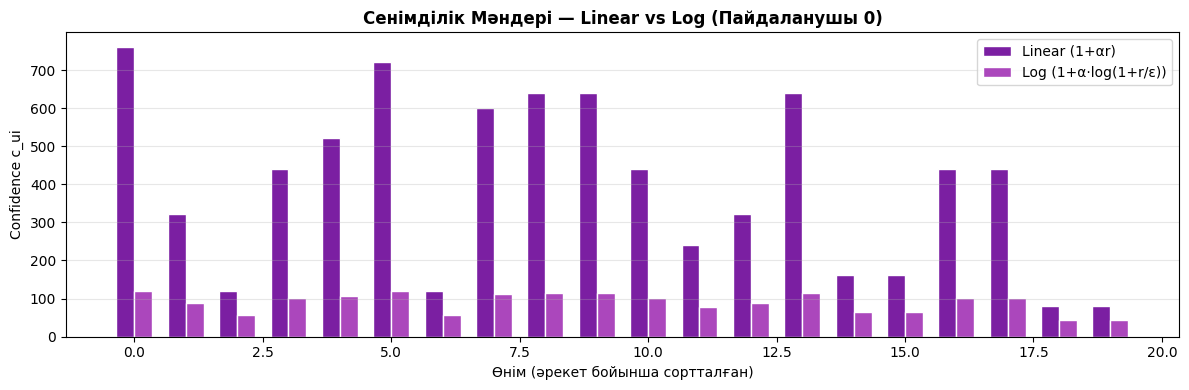

Linear C: мин=41, макс=761
Log    C: мин=28.73, макс=120.83


In [5]:
# ============================================================
### TODO ###
# build_confidence() арқылы P жəне C матрицаларын жасаңыз.
# mode='linear' жəне mode='log' нəтижелерін салыстырыңыз.
# Бір пайдаланушы үшін C мəндерін bar chart-та бейнелеңіз.
# ============================================================
P_lin, C_lin = build_confidence(implicit_raw, alpha=40, mode='linear')    # implicit_raw
P_log, C_log = build_confidence(implicit_raw, alpha=40, mode='log')

# Пайдаланушы 0 үшін салыстыру
u0_idx   = 0
u0_items = np.where(implicit_raw[u0_idx] > 0)[0][:20]

x = np.arange(len(u0_items))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, C_lin[u0_idx, u0_items], width,
       label='Linear (1+αr)', color='#7b1fa2', edgecolor='white')
ax.bar(x + width/2, C_log[u0_idx, u0_items], width,
       label='Log (1+α·log(1+r/ε))', color='#ab47bc', edgecolor='white')
ax.set_title('Сенімділік Мəндері — Linear vs Log (Пайдаланушы 0)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Өнім (əрекет бойынша сортталған)')
ax.set_ylabel('Confidence c_ui')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Linear C: мин={C_lin[C_lin>1].min():.0f}, макс={C_lin.max():.0f}")
print(f"Log    C: мин={C_log[C_log>1].min():.2f}, макс={C_log.max():.2f}")

## 4-бөлім: SLIM — Гиперпараметрлер Іздеу

In [6]:
class SLIMFull:
    """
    SLIM: Sparse Linear Methods for Top-N Recommendation.
    alpha жəне l1_ratio гиперпараметрлерімен.
    """
    def __init__(self, alpha=0.1, l1_ratio=0.5, max_iter=300):
        self.alpha     = alpha
        self.l1_ratio  = l1_ratio
        self.max_iter  = max_iter
        self.W_        = None

    def fit(self, R, verbose=False):
        n_users, n_items = R.shape
        self.W_          = np.zeros((n_items, n_items))

        for j in range(n_items):
            y_j = R[:, j]
            if y_j.sum() == 0:
                continue
            X_j = np.delete(R, j, axis=1)
            model = ElasticNet(
                alpha=self.alpha,
                l1_ratio=self.l1_ratio,
                positive=True,
                max_iter=self.max_iter,
                fit_intercept=False,
                warm_start=True
            )
            model.fit(X_j, y_j)
            coef = model.coef_
            self.W_[:j, j]   = coef[:j]
            self.W_[j+1:, j] = coef[j:]

            if verbose and (j + 1) % 50 == 0:
                print(f"  SLIM: {j+1}/{n_items}")

        return self

    def recommend(self, user_idx, R, top_n=10):
        scores  = R[user_idx] @ self.W_
        unrated = np.where(R[user_idx] == 0)[0]
        if len(unrated) == 0:
            return np.array([]), np.array([])
        top_idx = unrated[np.argsort(scores[unrated])[::-1][:top_n]]
        return top_idx, scores[top_idx]

    @property
    def sparsity(self):
        return (self.W_ == 0).mean()

print("SLIMFull класы анықталды.")

SLIMFull класы анықталды.


In [7]:
# ============================================================
### TODO ###
# alpha жəне l1_ratio-ның W матрицасы сиректігіне əсерін зерттеңіз.
# Бинарлы preference (P) матрицасын пайдаланыңыз.
#
# alpha_list   = [0.001, 0.01, 0.1, 1.0]
# l1_ratio_list= [0.1, 0.5, 0.9]
#
# Əр комбинация үшін SLIM үйретіп:
#   - W матрицасының сиректігін (sparsity)
#   - Нөлдік емес салмақтардың орташа мəнін шығарыңыз.
# ============================================================
# Небольшой подматрица для скорости
P_sub = P_lin[:100, :80]

alpha_list    = [0.001, 0.01, 0.1, 1.0]
l1_ratio_list = [0.1, 0.5, 0.9]

sparsity_grid = np.zeros((len(alpha_list), len(l1_ratio_list)))

print(f"{'alpha':>8} {'l1_ratio':>10} {'Сиректік':>12} {'Орт. салмақ':>14}")
print("-" * 48)

for i, alpha in enumerate(alpha_list):
    for j, l1r in enumerate(l1_ratio_list):
        slim_tmp = SLIMFull(alpha=alpha, l1_ratio=l1r)   # alpha, l1r
        slim_tmp.fit(P_sub)
        sp  = slim_tmp.sparsity
        nz  = slim_tmp.W_[slim_tmp.W_ > 0].mean() if (slim_tmp.W_ > 0).any() else 0
        sparsity_grid[i, j] = sp
        print(f"{alpha:>8.3f} {l1r:>10.1f} {sp:>12.2%} {nz:>14.4f}")

   alpha   l1_ratio     Сиректік    Орт. салмақ
------------------------------------------------
   0.001        0.1       93.41%         0.1913
   0.001        0.5       93.55%         0.1887
   0.001        0.9       93.69%         0.1861
   0.010        0.1       93.16%         0.1220
   0.010        0.5       94.48%         0.0892
   0.010        0.9       96.58%         0.0651
   0.100        0.1       97.39%         0.0530
   0.100        0.5       99.47%         0.1224
   0.100        0.9       99.69%         0.1670
   1.000        0.1       99.53%         0.0795
   1.000        0.5       99.95%         0.1678
   1.000        0.9      100.00%         0.0000


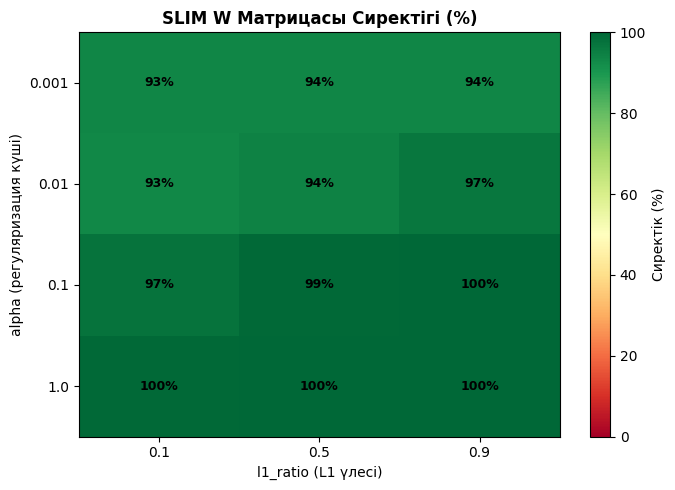

In [8]:
# Сиректік жылу картасы
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(sparsity_grid * 100, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Сиректік (%)')
ax.set_xticks(range(len(l1_ratio_list)))
ax.set_yticks(range(len(alpha_list)))
ax.set_xticklabels([str(r) for r in l1_ratio_list])
ax.set_yticklabels([str(a) for a in alpha_list])
ax.set_xlabel('l1_ratio (L1 үлесі)')
ax.set_ylabel('alpha (регуляризация күші)')
ax.set_title('SLIM W Матрицасы Сиректігі (%)', fontsize=12, fontweight='bold')
for i in range(len(alpha_list)):
    for j in range(len(l1_ratio_list)):
        ax.text(j, i, f'{sparsity_grid[i,j]*100:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 5-бөлім: iALS — Implicit ALS

In [9]:
class iALS:
    """
    Weighted Matrix Factorization for Implicit Feedback (Hu et al. 2008).
    Objective:
      min Σ_{u,i} c_ui (p_ui - u_u·v_i)² + λ(||U||²_F + ||V||²_F)
    """
    def __init__(self, n_factors=20, n_epochs=20, reg=0.1,
                 alpha=40, random_state=42):
        self.n_factors    = n_factors
        self.n_epochs     = n_epochs
        self.reg          = reg
        self.alpha        = alpha
        self.random_state = random_state
        self.losses_      = []

    def fit(self, R_implicit):
        rng  = np.random.RandomState(self.random_state)
        P, C = build_confidence(R_implicit, self.alpha, mode='log')
        n_u, n_i = P.shape
        K        = self.n_factors

        self.U_ = rng.randn(n_u, K) * 0.01
        self.V_ = rng.randn(n_i, K) * 0.01

        lambda_I = self.reg * np.eye(K)

        for epoch in range(self.n_epochs):
            # U жаңарту: əр пайдаланушы үшін
            for u in range(n_u):
                c_u    = C[u]                   # (n_i,)
                p_u    = P[u]                   # (n_i,)
                # C_u диагональ матрицасы
                # V.T C_u V + λI жуықтамасы (тек c_ui > 1 позициялар)
                A = self.V_.T @ (self.V_ * c_u[:, None]) + lambda_I
                b = self.V_.T @ (c_u * p_u)
                self.U_[u] = np.linalg.solve(A, b)

            # V жаңарту: əр өнім үшін
            for i in range(n_i):
                c_i = C[:, i]
                p_i = P[:, i]
                A   = self.U_.T @ (self.U_ * c_i[:, None]) + lambda_I
                b   = self.U_.T @ (c_i * p_i)
                self.V_[i] = np.linalg.solve(A, b)

            # Шығын = салмақты MSE
            R_pred = self.U_ @ self.V_.T
            loss   = np.sum(C * (P - R_pred) ** 2) + \
                     self.reg * (np.sum(self.U_**2) + np.sum(self.V_**2))
            self.losses_.append(loss)

            if (epoch + 1) % 5 == 0:
                print(f"  Дəуір {epoch+1:3d}: Шығын = {loss:.2f}")

        return self

    def recommend(self, user_idx, R_implicit, top_n=10):
        scores  = self.U_[user_idx] @ self.V_.T
        # Əрекет жасамаған өнімдерді ұсынамыз
        unseen  = np.where(R_implicit[user_idx] == 0)[0]
        top_idx = unseen[np.argsort(scores[unseen])[::-1][:top_n]]
        return top_idx, scores[top_idx]

print("iALS класы анықталды.")

iALS класы анықталды.


iALS үйретілуде...
  Дəуір   5: Шығын = 26054.67
  Дəуір  10: Шығын = 17173.70
  Дəуір  15: Шығын = 13309.75
  Дəуір  20: Шығын = 11101.92
iALS үйрету аяқталды.


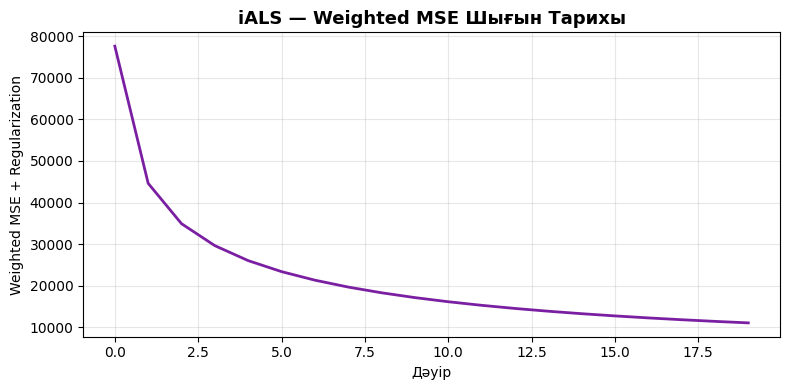

In [13]:
# ============================================================
### TODO ###
# iALS моделін implicit_raw деректерінде үйретіңіз.
# n_factors=20, n_epochs=20, reg=0.1, alpha=40 параметрімен.
# Шығын тарихын бейнелеңіз.
# ============================================================
print("iALS үйретілуде...")
ials = iALS(n_factors=20 ,n_epochs=20, reg=0.1, alpha=40)   # 20,20,0.1,40
ials.fit(implicit_raw)
print("iALS үйрету аяқталды.")

plt.figure(figsize=(8, 4))
plt.plot(ials.losses_, linewidth=2, color='#7b1fa2')   # ials.losses_
plt.title('iALS — Weighted MSE Шығын Тарихы', fontsize=13, fontweight='bold')
plt.xlabel('Дəуір')
plt.ylabel('Weighted MSE + Regularization')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6-бөлім: Бағалау Метрикалары

In [14]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / k

def recall_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / (len(relevant) + 1e-10)

def ndcg_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    dcg   = sum(1/np.log2(i+2) for i,r in enumerate(rec_k) if r in relevant)
    idcg  = sum(1/np.log2(i+2) for i in range(min(len(relevant),k)))
    return dcg / (idcg + 1e-10)

def average_precision(recommended, relevant, k):
    hits, score = 0, 0.0
    for i, r in enumerate(recommended[:k]):
        if r in relevant:
            hits  += 1
            score += hits / (i + 1)
    return score / (min(len(relevant), k) + 1e-10)

print("Метрика функциялары анықталды.")

Метрика функциялары анықталды.


In [18]:
# ============================================================
### TODO ###
# Leave-One-Out бағалау:
# Əр пайдаланушы үшін бір өнімді алып тастап,
# оны əр əдіс таба ала ма — тексереміз.
# ============================================================
K_EVAL  = 10
N_EVAL  = 50  # тестілейтін пайдаланушы саны

# Popularity-based baseline: ең жиі əрекет жасалған өнімдер
item_pop = implicit_raw.sum(axis=0)
pop_recs = np.argsort(item_pop)[::-1]  # жиілікке қарай сортталған

# ---- LOO үшін бір ғана train_R матрицасын дайындаймыз ----
# (əр пайдаланушының соңғы белгілі əрекетін алып тастаймыз)
train_R = implicit_raw.copy()
held_out_map = {}   # user -> held_out item

for u in range(N_EVAL):
    seen_items = np.where(implicit_raw[u] > 0)[0]
    if len(seen_items) < 3:
        continue
    held_out = seen_items[-1]
    held_out_map[u] = held_out
    train_R[u, held_out] = 0

# ---- SLIM жəне iALS моделін БІР РЕТ қана (барлық N_EVAL пайдаланушыға) үйретеміз ----
print("SLIM үйретілуде...")
slim_eval = SLIMFull(alpha=0.05, l1_ratio=0.7)
slim_eval.fit((train_R > 0).astype(float))
print("Аяқталды.")

print("iALS үйретілуде...")
ials_eval = iALS(n_factors=10, n_epochs=10, reg=0.1, alpha=20)
ials_eval.fit(train_R)
print("Аяқталды.")

results = {}

for method in ['Random', 'Popularity', 'SLIM', 'iALS']:
    precisions, recalls, ndcgs, aps = [], [], [], []

    for u in range(N_EVAL):
        if u not in held_out_map:
            continue

        held_out = [held_out_map[u]]
        unseen   = np.where(train_R[u] == 0)[0]

        if method == 'Random':
            recs = np.random.choice(unseen, min(K_EVAL, len(unseen)), replace=False).tolist()
        elif method == 'Popularity':
            recs = [i for i in pop_recs if i in unseen][:K_EVAL]
        elif method == 'SLIM':
            r_items, _ = slim_eval.recommend(u, train_R, top_n=K_EVAL)
            recs = r_items.tolist()
        else:  # iALS
            r_items, _ = ials_eval.recommend(u, train_R, top_n=K_EVAL)
            recs = r_items.tolist()

        precisions.append(precision_at_k(recs, held_out, K_EVAL))
        recalls.append(recall_at_k(recs, held_out, K_EVAL))
        ndcgs.append(ndcg_at_k(recs, held_out, K_EVAL))
        aps.append(average_precision(recs, held_out, K_EVAL))

    results[method] = {
        'Precision@K': np.mean(precisions),
        'Recall@K':    np.mean(recalls),
        'NDCG@K':      np.mean(ndcgs),
        'MAP@K':       np.mean(aps)
    }
    print(f"{method}: P@K={results[method]['Precision@K']:.4f}, "
          f"R@K={results[method]['Recall@K']:.4f}, "
          f"NDCG@K={results[method]['NDCG@K']:.4f}, "
          f"MAP@K={results[method]['MAP@K']:.4f}")

SLIM үйретілуде...
Аяқталды.
iALS үйретілуде...
  Дəуір   5: Шығын = 15716.26
  Дəуір  10: Шығын = 11981.43
Аяқталды.
Random: P@K=0.0020, R@K=0.0200, NDCG@K=0.0100, MAP@K=0.0067
Popularity: P@K=0.1000, R@K=1.0000, NDCG@K=1.0000, MAP@K=1.0000
SLIM: P@K=0.1000, R@K=1.0000, NDCG@K=0.8869, MAP@K=0.8483
iALS: P@K=0.1000, R@K=1.0000, NDCG@K=0.7832, MAP@K=0.7097


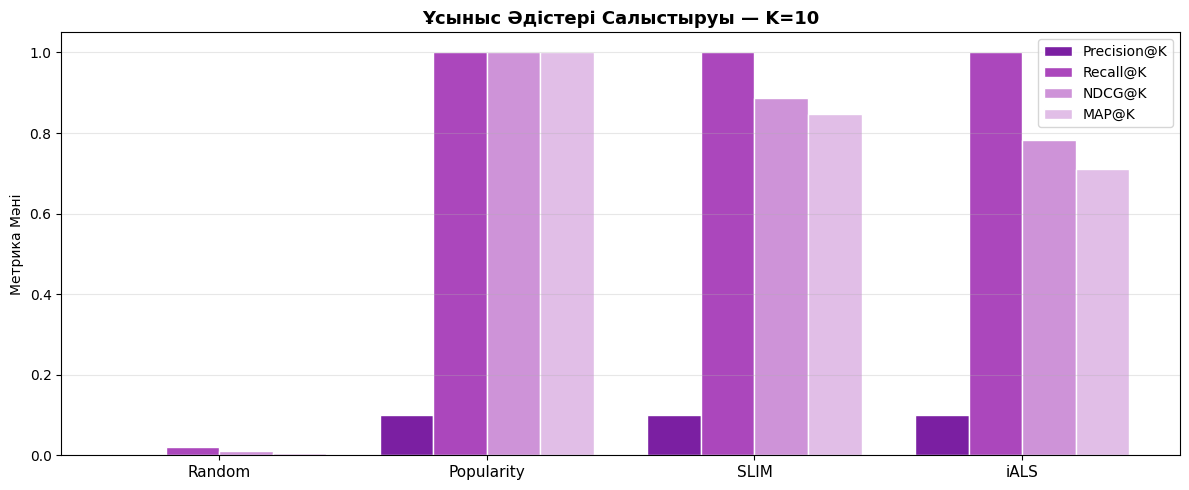

In [19]:
# ============================================================
### TODO ###
# Барлық əдістердің метрикаларын grouped bar chart-та бейнелеңіз.
# X осі — əдістер, grouped bars — 4 метрика.
# ============================================================
methods    = list(results.keys())
metrics_k  = ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP@K']
colors_m   = ['#7b1fa2', '#ab47bc', '#ce93d8', '#e1bee7']

x     = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metrics_k, colors_m)):
    vals = [results[m][metric] for m in methods]
    ax.bar(x + i*width - 1.5*width,vals, width,   # vals
           label=metric, color=color, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_title(f'Ұсыныс Əдістері Салыстыруы — K={K_EVAL}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Метрика Мəні')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7-бөлім: Барлық Зертхана Бойынша Жалпы Қорытынды кестесі

In [20]:
# ============================================================
### TODO ###
# Барлық əдістер туралы жинақты кесте жасаңыз.
# Əр əдіс үшін: артықшылығы, кемшілігі, деректер түрі,
# сиректік мəселесін шешеді ме, суық іске қосу мəселесін шешеді ме.
# ============================================================
summary = pd.DataFrame([
    {
        'Əдіс': 'User-CF',
        'Артықшылығы':   'Интерпретациялауы оңай',
        'Кемшілігі':     'Өте сирек матрицада нашар',
        'Деректер':      'Explicit',
        'Сиректік':      'Мəселе бар',
        'Cold Start':    'Мəселе бар'
    },
    {
        'Əдіс': 'Item-CF',
        'Артықшылығы':   'Тұрақтырақ, өнімдер сирек өзгереді',
        'Кемшілігі':     'Өнім саны артса есептеу қымбаттайды',
        'Деректер':      'Explicit',
        'Сиректік':      'Ішінара',
        'Cold Start':    'Жаңа пайдаланушыға'
    },
    {
        'Əдіс': 'ALS (MF)',
        'Артықшылығы':   'Масштабталады, параллельдеуге ыңғайлы',
        'Кемшілігі':     'Латентті факторлар интерпретациясы қиын',
        'Деректер':      'Explicit/Implicit',
        'Сиректік':      'Жоқ (жуықтайды)',
        'Cold Start':    'Мəселе бар'
    },
    {
        'Əдіс': 'SLIM',
        'Артықшылығы':   'Жоғары дəлдік, сирек салмақтар',
        'Кемшілігі':     'Үлкен деректерде үйрету баяу',
        'Деректер':      'Implicit (preference)',
        'Сиректік':      'Жоқ (L1 арқасында)',
        'Cold Start':    'Мəселе бар'
    },
    {
        'Əдіс': 'iALS',
        'Артықшылығы':   'Implicit деректерге арнайы оңтайландырылған',
        'Кемшілігі':     'Салмақ гиперпараметрін таңдау қиын',
        'Деректер':      'Implicit',
        'Сиректік':      'Жоқ',
        'Cold Start':    'Мəселе бар'
    },
])

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 150)
print(summary.to_string(index=False))

    Əдіс                                 Артықшылығы                               Кемшілігі              Деректер           Сиректік         Cold Start
 User-CF                      Интерпретациялауы оңай               Өте сирек матрицада нашар              Explicit         Мəселе бар         Мəселе бар
 Item-CF          Тұрақтырақ, өнімдер сирек өзгереді     Өнім саны артса есептеу қымбаттайды              Explicit            Ішінара Жаңа пайдаланушыға
ALS (MF)       Масштабталады, параллельдеуге ыңғайлы Латентті факторлар интерпретациясы қиын     Explicit/Implicit    Жоқ (жуықтайды)         Мəселе бар
    SLIM              Жоғары дəлдік, сирек салмақтар            Үлкен деректерде үйрету баяу Implicit (preference) Жоқ (L1 арқасында)         Мəселе бар
    iALS Implicit деректерге арнайы оңтайландырылған      Салмақ гиперпараметрін таңдау қиын              Implicit                Жоқ         Мəселе бар


## 8-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** SLIM неліктен `diag(W) = 0` жəне `W ≥ 0` шарттарын қояды? Бұл шарттар болмаса не болар еді?

> diag(W) = 0 – өнімнің өзін өзі болжауына жол бермейді.
W ≥ 0 – салмақтардың теріс болмауын қамтамасыз етеді, сондықтан ұсыныстар түсініктірек болады.
Егер бұл шарттар болмаса, модель дұрыс емес немесе мағынасыз байланыстарды үйренуі мүмкін.

**Сұрақ 2.** iALS-тегі сенімділік матрицасы неліктен əрекеттің нөл болуы маңызды деп есептейді? Ол «мен мұны ұнатпаймын» дегенді білдіре ме?

> Жоқ. Нөл «ұнатпаймын» дегенді білдірмейді. Ол тек пайдаланушының бұл өніммен әрекет жасамағанын көрсетеді. Сондықтан мұндай деректерге сенімділік төмен беріледі.

**Сұрақ 3.** NDCG мен MAP-тің айырмасы неде? Ретті ескеру қашан маңызды?

> NDCG – дұрыс ұсыныстардың тізімде қаншалықты жоғары тұрғанын бағалайды.
MAP – барлық дұрыс ұсыныстардың орташа дәлдігін бағалайды.
Рет әсіресе пайдаланушы көбіне алғашқы бірнеше ұсынысты ғана көретін жағдайда өте маңызды.

**Сұрақ 4.** Popularity-based baseline кейде күрделі əдістерді жеңеді. Бұл неліктен болуы мүмкін?

> Егер көптеген пайдаланушылар бірдей танымал өнімдерді таңдаса немесе деректер аз болса, ең танымал өнімдерді ұсыну жеткілікті жақсы нәтиже береді. Мұндай жағдайда күрделі модельдердің артықшылығы байқалмауы мүмкін.

## Жалпы Қорытынды: Ұсыныс Жүйелері Зертханалар Сериясы

Төрт зертхананы аяқтай отырып, сіз ұсыныс жүйелерінің негізгі əдістерін нөлден іске асырдыңыз.

**Зертхана 0 — Шолу:** CF, ALS, SLIM, implicit feedback жəне Precision/Recall/NDCG метрикаларын бір дəптерде демонстрациялауды орындадыңыз.

**Зертхана 1 — Коллаборативті Фильтрация:** Kosinus vs Pearson ұқсастықтарын салыстырдыңыз, k-NN LOO RMSE зерттедіңіз, матрица тығыздығының əсерін байқадыңыз, суық іске қосу мəселесін эксперимент арқылы талдадыңыз.

**Зертхана 2 — ALS:** Аналитикалық жаңарту формуласын жəне bias терминдерін іске асырдыңыз, Grid search арқылы гиперпараметрлер оңтайландырдыңыз, ALS vs SGD-MF конвергенциясын салыстырдыңыз.

**Зертхана 3 — SLIM + iALS:** ElasticNet SLIM W матрицасының сиректігін alpha/l1_ratio арқылы зерттедіңіз, Weighted MF (iALS) сенімділік матрицасымен үйреттіңіз, LOO бағалауда барлық əдістерді 4 метрикамен салыстырдыңыз.

<div style="background-color:#f3e5f5; border-left:5px solid #7b1fa2; padding:15px 18px; border-radius:8px; margin-top:16px;">
<strong>Əрі қарай:</strong> Neural Collaborative Filtering (NCF), BERT4Rec, LightGCN, Two-Tower модельдері, Knowledge Graph-негізді ұсыныстар — осы зертханалардағы негіздер заманауи жүйелердің базасы.
</div>